<a href="https://colab.research.google.com/github/helenjoy/Deeplearning26/blob/main/linear_regresssion_ml_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Simple  Linear Regression

# Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Explanation: Import Libraries

This block imports the necessary Python libraries:
- `pandas` as `pd`: Used for data manipulation and analysis, especially with DataFrames.
- `numpy` as `np`: Used for numerical operations, especially with arrays.
- `matplotlib.pyplot` as `plt`: Used for creating static, interactive, and animated visualizations in Python.

# Step 2: Upload CSV File

In [4]:
from google.colab import files
uploaded = files.upload()

Saving placement.csv to placement.csv


### Explanation: Upload CSV File

This block handles the upload of the `placement.csv` file from your local machine to the Colab environment. The `files.upload()` function from `google.colab` prompts you to select and upload the file.

# Step 3: Read Dataset

In [5]:
df = pd.read_csv('placement.csv')

### Explanation: Read Dataset

After uploading, this cell reads the `placement.csv` file into a pandas DataFrame named `df`. This DataFrame will store our data for analysis.

# Step 4: Display First 5 Rows

In [ ]:
print(df.head())

   cgpa  package
0  6.89     3.26
1  5.12     1.98
2  7.82     3.25
3  7.42     3.67
4  6.94     3.57


### Explanation: Display First 5 Rows

The `df.head()` function is used here to display the first 5 rows of the DataFrame. This gives a quick overview of the data structure and content, showing the `cgpa` and `package` columns.

# Step 5: Scatter Plot

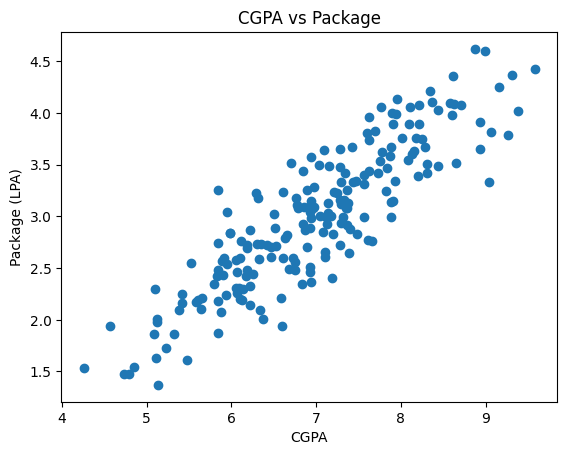

In [ ]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel("CGPA")
plt.ylabel("Package (LPA)")
plt.title("CGPA vs Package")
plt.show()

### Explanation: Scatter Plot

This block generates a scatter plot to visualize the relationship between `cgpa` and `package`.
- `plt.scatter(df['cgpa'], df['package'])`: Creates the scatter plot with `cgpa` on the x-axis and `package` on the y-axis.
- `plt.xlabel("CGPA")`, `plt.ylabel("Package (LPA)")`, `plt.title("CGPA vs Package")`: Set the labels for the axes and the title of the plot for clarity.
- `plt.show()`: Displays the generated plot.

# Step 6: Split Features and Target

In [ ]:
X = df[['cgpa']]
y = df['package']

### Explanation: Split Features and Target

In this step, we prepare our data for the linear regression model:
- `X = df[['cgpa']]`: The independent variable (feature) `X` is set to the 'cgpa' column. We use `[['cgpa']]` to ensure `X` is a DataFrame, which is typically required by scikit-learn models for a single feature.
- `y = df['package']`: The dependent variable (target) `y` is set to the 'package' column.

# Step 7: Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

### Explanation: Train Test Split

This block splits the dataset into training and testing sets:
- `from sklearn.model_selection import train_test_split`: Imports the function for splitting data.
- `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)`: Divides `X` and `y` into training (80%) and testing (20%) sets. `test_size=0.2` specifies that 20% of the data will be used for testing, and `random_state=2` ensures reproducibility of the split.

# Step 8: Import and Train Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

### Explanation: Import and Train Linear Regression Model

Here, the linear regression model is initialized and trained:
- `from sklearn.linear_model import LinearRegression`: Imports the Linear Regression model class.
- `lr = LinearRegression()`: Creates an instance of the Linear Regression model.
- `lr.fit(X_train, y_train)`: Trains the model using the training data (`X_train` for features and `y_train` for target). The model learns the optimal slope and intercept during this step.

# Step 9: Predict Values

In [ ]:
y_pred = lr.predict(X_test)

### Explanation: Predict Values

This cell uses the trained linear regression model to make predictions on the test set:
- `y_pred = lr.predict(X_test)`: The `predict()` method takes the test features (`X_test`) and returns the predicted `package` values (`y_pred`).

# Step 10: Compare Actual vs Predicted

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head())

   Actual  Predicted
0    4.10   3.891116
1    3.49   3.093245
2    2.08   2.384646
3    2.33   2.574349
4    1.94   1.653729


### Explanation: Compare Actual vs Predicted

This block compares the actual `package` values from the test set with the predicted values:
- A new DataFrame `comparison` is created to hold both the actual and predicted values for easy comparison.
- `print(comparison.head())`: Displays the first few rows of this comparison DataFrame.

# Step 11: Predict for One Sample Input

In [ ]:
sample_prediction = lr.predict([[8.58]])

print("\nPredicted Package for CGPA 8.58:")
print(sample_prediction)


Predicted Package for CGPA 8.58:
[3.89111601]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Explanation: Predict for One Sample Input

This demonstrates how to use the trained model to predict the package for a new, single CGPA value:
- `sample_prediction = lr.predict([[8.58]])`: Predicts the package for a CGPA of 8.58. Note that the input `[[8.58]]` is a 2D array, which is the format expected by `predict()` for a single sample.
- The predicted value is then printed.

# Step 12: Plot Regression Line

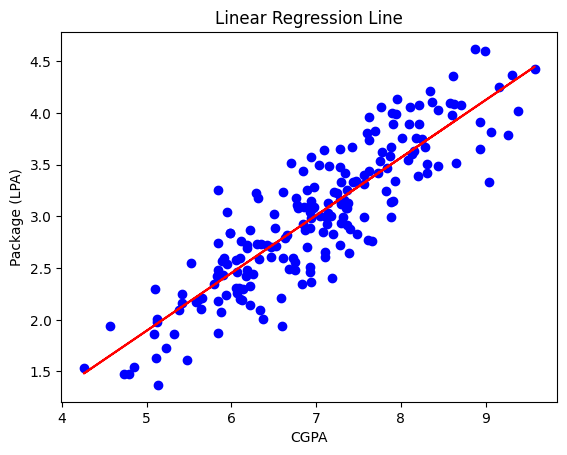

In [ ]:
plt.scatter(df['cgpa'], df['package'], color='blue')

plt.plot(
    X_train,
    lr.predict(X_train),
    color='red'
)

plt.xlabel("CGPA")
plt.ylabel("Package (LPA)")
plt.title("Linear Regression Line")
plt.show()

### Explanation: Plot Regression Line

This block visualizes the regression line along with the original scatter plot:
- `plt.scatter(df['cgpa'], df['package'], color='blue')`: Plots the original data points in blue.
- `plt.plot(X_train, lr.predict(X_train), color='red')`: Draws the linear regression line. It uses the training features (`X_train`) and the predictions made by the model on `X_train` to plot the line in red.
- Axes labels and title are set, and the plot is displayed.

# Step 13: Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("MAE :", mae)
print("MSE :", mse)
print("R2 Score :", r2)


Model Evaluation
MAE : 0.2884710931878175
MSE : 0.12129235313495527
R2 Score : 0.780730147510384


### Explanation: Model Evaluation

This step evaluates the performance of the linear regression model using common metrics:
- `from sklearn.metrics import ...`: Imports `mean_absolute_error`, `mean_squared_error`, and `r2_score`.
- `mae = mean_absolute_error(y_test, y_pred)`: Calculates the Mean Absolute Error, which is the average of the absolute differences between predictions and actual values.
- `mse = mean_squared_error(y_test, y_pred)`: Calculates the Mean Squared Error, which is the average of the squared differences between predictions and actual values. This penalizes larger errors more.
- `r2 = r2_score(y_test, y_pred)`: Calculates the R-squared score, which represents the proportion of the variance in the dependent variable that is predictable from the independent variable(s). A higher R-squared indicates a better fit.
- These evaluation metrics are then printed.

### Explanation of Evaluation Metrics Equations

These are the formulas for the evaluation metrics used:

1.  **Mean Absolute Error (MAE)**:

    $\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$

    Where:
    - $n$ is the number of data points.
    - $y_i$ is the actual value.
    - $\hat{y}_i$ is the predicted value.

    MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It's the average over the test sample of the absolute differences between prediction and actual observation where all individual differences have equal weight.

2.  **Mean Squared Error (MSE)**:

    $\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

    Where:
    - $n$ is the number of data points.
    - $y_i$ is the actual value.
    - $\hat{y}_i$ is the predicted value.

    MSE measures the average of the squares of the errors. It's a common metric because it penalizes larger errors more heavily than MAE, making it sensitive to outliers.

3.  **R-squared (R2 Score)**:

    $$ \text{R}^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} $$

    Where:
    - $n$ is the number of data points.
    - $y_i$ is the actual value.
    - $\hat{y}_i$ is the predicted value.
    - $\bar{y}$ is the mean of the actual values.

    The R-squared score, also known as the coefficient of determination, represents the proportion of the variance in the dependent variable that is predictable from the independent variable(s). It provides an indication of how well the model fits the observed data. An R2 score of 1 indicates a perfect fit, while a score of 0 suggests that the model explains none of the variability of the response data around its mean. A negative R2 score means the model is worse than simply predicting the mean of the target variable.

# Step 14: Coefficients

In [ ]:
print("\nSlope (m):", lr.coef_[0])
print("Intercept (b):", lr.intercept_)


Slope (m): 0.557951973425072
Intercept (b): -0.8961119222429144


### Explanation: Coefficients

Finally, this block prints the coefficients of the trained linear regression model:
- `lr.coef_[0]`: This is the slope (m) of the regression line, indicating how much the `package` is expected to change for a one-unit increase in `cgpa`.
- `lr.intercept_`: This is the intercept (b) of the regression line, which is the predicted `package` when `cgpa` is zero. In the context of CGPA, this might not have a direct real-world interpretation but is essential for the linear equation `y = mx + b`.

## LAB 3 : LINEAR REGRESSION

#### Step 1 : Import Libraries

In [2]:
import numpy as np
import pandas as pd

In [6]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


#### Step 4 : Separate Input and Output

In [7]:
X = df.iloc[:,0].values
y = df.iloc[:,1].values

print("X Values:")
print(X)

print("\nY Values:")
print(y)

X Values:
[6.89 5.12 7.82 7.42 6.94 7.89 6.73 6.75 6.09 8.31 5.32 6.61 8.94 6.93
 7.73 7.25 6.84 5.38 6.94 7.48 7.28 6.85 6.14 6.19 6.53 7.28 8.31 5.42
 5.94 7.15 7.36 8.1  6.96 6.35 7.34 6.87 5.99 5.9  8.62 7.43 9.38 6.89
 5.95 7.66 5.09 7.87 6.07 5.84 8.63 8.87 9.58 9.26 8.37 6.47 6.86 8.2
 5.84 6.6  6.92 7.56 5.61 5.48 6.34 9.16 7.36 7.6  5.11 6.51 7.56 7.3
 5.79 7.47 7.78 8.44 6.85 6.97 6.94 8.99 6.59 7.18 7.63 6.1  5.58 8.44
 4.26 4.79 7.61 8.09 4.73 6.42 7.11 6.22 7.9  6.79 5.83 6.63 7.11 5.98
 7.69 6.61 7.95 6.71 5.13 7.05 7.62 6.66 6.13 6.33 7.76 7.77 8.18 5.42
 8.58 6.94 5.84 8.35 9.04 7.12 7.4  7.39 5.23 6.5  5.12 5.1  6.06 7.33
 5.91 6.78 7.93 7.29 6.68 6.37 5.84 6.05 7.2  6.1  5.64 7.14 7.91 7.19
 7.91 6.76 6.93 4.85 6.17 5.84 6.07 5.66 7.57 8.28 6.3  6.12 7.37 7.94
 7.08 6.98 7.38 6.47 5.95 8.71 7.13 7.3  5.53 8.93 9.06 8.21 8.6  8.13
 8.65 9.31 6.22 8.01 6.93 6.75 7.32 7.04 6.29 7.09 8.15 7.14 6.19 8.22
 5.88 7.28 7.88 6.31 7.84 6.26 7.35 8.11 6.19 7.28 8.25 4.57 7.89 6.9

### Step 5 : Create Custom Linear Regression Class

In [8]:
class LR:

    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):

        num = 0
        den = 0

        for i in range(X_train.shape[0]):

            num = num + (
                (X_train[i] - X_train.mean()) *
                (y_train[i] - y_train.mean())
            )

            den = den + (
                (X_train[i] - X_train.mean()) *
                (X_train[i] - X_train.mean())
            )

        self.m = num / den

        self.b = y_train.mean() - (self.m * X_train.mean())

        print("Slope (m) =", self.m)
        print("Intercept (b) =", self.b)

    def predict(self, X_test):

        print("Input Value:", X_test)

        return self.m * X_test + self.b

### Step 6 : Train Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

print("Shape of X_train:", X_train.shape)

Shape of X_train: (160,)


### Step 7 : Train Model

In [10]:
lr = LR()

lr.fit(X_train, y_train)

Slope (m) = 0.5579519734250721
Intercept (b) = -0.8961119222429152


### Step 8 : Prediction

In [11]:
pred = lr.predict(X_test[0])

print("\nPredicted Package:", pred)

Input Value: 8.58

Predicted Package: 3.891116009744203


### Step 9 : Manual Formula Verification

In [12]:
print("\nVerification Values")
print("----------------------")

print("First X_train Value:", X_train[0])
print("Mean of X_train:", X_train.mean())
print("First X_test Value:", X_test[0])


Verification Values
----------------------
First X_train Value: 7.14
Mean of X_train: 6.989937500000001
First X_test Value: 8.58


### Step 10 : Plot Regression Line

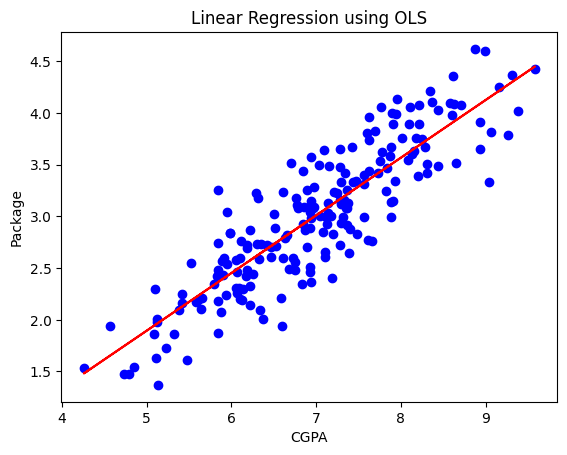

In [13]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color='blue')

# Regression Line
y_pred_line = lr.m * X + lr.b

plt.plot(X, y_pred_line, color='red')

plt.xlabel("CGPA")
plt.ylabel("Package")
plt.title("Linear Regression using OLS")

plt.show()